In [1]:
from proc import process_data
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import binomtest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("```")
results = process_data()
print("```")
results

```
total successes=38,541,103,221 local: (CPU: 1,683,911,973, GPU: 34,482,498,455)
total trials=101,436,250,000 local: (CPU: 4,432,000,000, GPU: 90,754,250,000)
statsmodels.stats.proportion.proportion_confint: (0.3799509567353272, 0.37995693065892194)
scipy.stats.binomtest: (alpha=0.05)              (0.37995095673562, 0.37995693065889585)
CI Width: 5.9739235947486868E-06
Standard Error: 1.5239855894008383e-06
Point Estimate: 0.3799539436936992
```


,regular,seed,N,gpu
0,190325,-1,500000,True
1,189899,-1,500000,True
2,190316,-1,500000,True
3,189733,-1,500000,True
4,190180,-1,500000,True
...,...,...,...,...
607603,3819,850716265,10000,False
607604,3730,410805867,10000,False
607605,3843,478466000,10000,False
607606,3857,551352958,10000,False


In [3]:
gpu_results = results[results["gpu"]]
cpu_results = results[(~results["gpu"])&(results["seed"]!=-1)]
vil_results = results.iloc[len(results)-1]

In [4]:
alpha = 0.05
results["p_hat"] = results["regular"] / results["N"]
cpu_results["p_hat"] = cpu_results["regular"] / cpu_results["N"]
gpu_results["p_hat"] = gpu_results["regular"] / gpu_results["N"]
vil_results["p_hat"] = vil_results["regular"] / vil_results["N"]

In [5]:
# CPU CALCS
cpu_results["cumulative_successes"] = np.cumsum(cpu_results["regular"])
cpu_results["cumulative_trials"]    = np.cumsum(cpu_results["N"])

cpu_results["p_hat_n"]              = cpu_results["cumulative_successes"] / cpu_results["cumulative_trials"]

cpu_lower, cpu_upper = proportion_confint(cpu_results["cumulative_successes"], cpu_results["cumulative_trials"], alpha=alpha, method='beta')

cpu_results["lower"] = cpu_lower
cpu_results["upper"] = cpu_upper
cpu_results

,regular,seed,N,gpu,p_hat,cumulative_successes,cumulative_trials,p_hat_n,lower,upper
164407,3851,1560148770,10000,False,0.3851,3851,10000,0.385100,0.375547,0.394720
164408,3671,3222033341,10000,False,0.3671,7522,20000,0.376100,0.369380,0.382856
164409,3880,4144223430,10000,False,0.3880,11402,30000,0.380067,0.374569,0.385587
164410,3804,1402486079,10000,False,0.3804,15206,40000,0.380150,0.375389,0.384928
164411,3862,1917096892,10000,False,0.3862,19068,50000,0.381360,0.377100,0.385634
...,...,...,...,...,...,...,...,...,...,...
607602,3789,2019616239,10000,False,0.3789,1683896724,4431960000,0.379944,0.379930,0.379958
607603,3819,850716265,10000,False,0.3819,1683900543,4431970000,0.379944,0.379930,0.379958
607604,3730,410805867,10000,False,0.3730,1683904273,4431980000,0.379944,0.379930,0.379958
607605,3843,478466000,10000,False,0.3843,1683908116,4431990000,0.379944,0.379930,0.379958


In [6]:
# GPU CALCS
gpu_results["cumulative_successes"] = np.cumsum(gpu_results["regular"])
gpu_results["cumulative_trials"]    = np.cumsum(gpu_results["N"])

gpu_results["p_hat_n"]              = gpu_results["cumulative_successes"] / gpu_results["cumulative_trials"]

gpu_lower, gpu_upper = proportion_confint(gpu_results["cumulative_successes"], gpu_results["cumulative_trials"], alpha=alpha, method='beta')

gpu_results["lower"] = gpu_lower
gpu_results["upper"] = gpu_upper
gpu_results

,regular,seed,N,gpu,p_hat,cumulative_successes,cumulative_trials,p_hat_n,lower,upper
0,190325,-1,500000,True,0.380650,190325,500000,0.380650,0.379304,0.381998
1,189899,-1,500000,True,0.379798,380224,1000000,0.380224,0.379272,0.381176
2,190316,-1,500000,True,0.380632,570540,1500000,0.380360,0.379583,0.381137
3,189733,-1,500000,True,0.379466,760273,2000000,0.380136,0.379464,0.380810
4,190180,-1,500000,True,0.380360,950453,2500000,0.380181,0.379579,0.380783
...,...,...,...,...,...,...,...,...,...,...
164402,190228,-1,500000,True,0.380456,34481737446,90752250000,0.379955,0.379951,0.379958
164403,190686,-1,500000,True,0.381372,34481928132,90752750000,0.379955,0.379951,0.379958
164404,189618,-1,500000,True,0.379236,34482117750,90753250000,0.379955,0.379951,0.379958
164405,190722,-1,500000,True,0.381444,34482308472,90753750000,0.379955,0.379951,0.379958


C:\Users\fired\AppData\Local\Temp\ipykernel_43424\1682122753.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


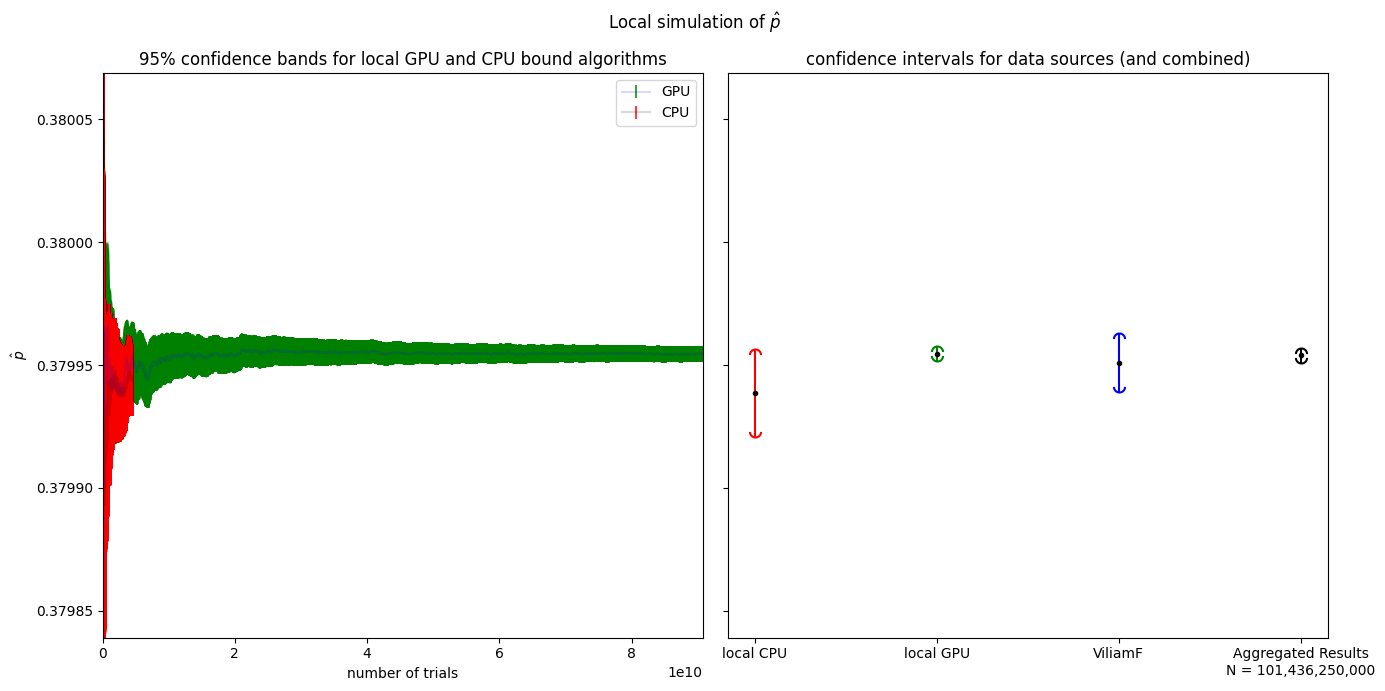

In [ ]:
from plotting_utils import vertical_paren_errorbar

CPU_color = 'red'
GPU_color = 'green'
VIL_color = 'blue'
AGG_color = 'black'
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
# LHS
axes[0].set_title(rf"{1-alpha:.0%} confidence bands for local GPU and CPU bound algorithms")

axes[0].errorbar(x=gpu_results["cumulative_trials"], y=gpu_results["p_hat_n"], yerr=(gpu_results["upper"]-gpu_results["lower"]) / 2, fmt='b-', ecolor=GPU_color, alpha=0.15, label="GPU")
axes[0].errorbar(x=cpu_results["cumulative_trials"], y=cpu_results["p_hat_n"], yerr=(cpu_results["upper"]-cpu_results["lower"]) / 2, fmt='k-', ecolor=CPU_color, alpha=0.15, label="CPU")

#ax.hlines()

leg = axes[0].legend()
for t in leg.legend_handles:
    t.set_alpha(0.75)

_x = np.sum(results["regular"])
_N = np.sum(results["N"])
p = _x / _N
eps = 1.15e-4

axes[0].set_xlim(0, np.max(pd.concat([gpu_results["cumulative_trials"], cpu_results["cumulative_trials"]]))+10)
axes[0].set_ylim(p - eps, p + eps)
axes[0].set_xlabel("number of trials")
axes[0].set_ylabel("$\\hat{p}$")

# RHS

axes[1].set_title(rf"confidence intervals for data sources (and combined)")

agg_lower, agg_upper = proportion_confint(_x, _N, alpha=alpha, method='beta')
agg_CI = (p - agg_lower, p, agg_upper - p)
gpu_CI = gpu_results.loc[len(gpu_results)-1, ["lower", "p_hat_n", "upper"]]
cpu_CI = cpu_results.loc[len(cpu_results)-1, ["lower", "p_hat_n", "upper"]]
gpu_CI["lower"] = gpu_CI["p_hat_n"] - gpu_CI["lower"]
cpu_CI["lower"] = cpu_CI["p_hat_n"] - cpu_CI["lower"]
gpu_CI["upper"] = gpu_CI["upper"] - gpu_CI["p_hat_n"]
cpu_CI["upper"] = cpu_CI["upper"] - cpu_CI["p_hat_n"] 
vil_lower, vil_upper = proportion_confint(vil_results["regular"], vil_results["N"], alpha=alpha, method='beta')
p_vil = vil_results["regular"] / vil_results["N"]
vil_CI = (p_vil - vil_lower , p_vil, vil_upper - p_vil)

labels = ["local CPU", "local GPU", "ViliamF", f"Aggregated Results\nN = {_N:,}"]
means  = [cpu_CI["p_hat_n"], gpu_CI["p_hat_n"], vil_CI[1], agg_CI[1]]
limits = np.array([cpu_CI[["lower", "upper"]], gpu_CI[["lower", "upper"]], [vil_CI[0], vil_CI[2]], [agg_CI[0], agg_CI[2]]]).T

pallette = [CPU_color, GPU_color, VIL_color, AGG_color]
vertical_paren_errorbar(axes[1], labels, means, yerr=limits, fmt='k.', ecolor=pallette, capsize=8, cap_aspect_y=0.75, cap_aspect_x=0.75)

fig.suptitle(f"simulation of $\\hat{{p}}$ in octahedron problem")
fig.tight_layout()

fig.show()